# Описание датасета


Биология (орнитология, морфометрия), [Palmer Archipelago (Antarctica) Penguin Data](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data), реальные данные.

Данные собраны д-ром Kristen Gorman совместно со станцией Palmer Station, Антарктида, в рамках сети долгосрочных экологических исследований (Palmer Station LTER, Long Term Ecological Research Network) в 2007–2009 гг.

Датасет содержит 344 наблюдения по трём видам пингвинов (Adelie, Chinstrap, Gentoo), обитающим на трёх островах архипелага Палмера.

## Атрибуты датасета


| Атрибут | Тип | Что обозначает |
|---|---|---|
| species | категориальный (строковый) | вид пингвина: Adelie, Gentoo, Chinstrap |
| island | категориальный (строковый) | остров архипелага Палмера, на котором произведено наблюдение: Biscoe, Dream, Torgersen |
| culmen_length_mm | числовой (вещественный) | длина клюва (culmen length), мм |
| culmen_depth_mm | числовой (вещественный) | глубина (высота) клюва, мм |
| flipper_length_mm | числовой (целый) | длина ласта, мм |
| body_mass_g | числовой (целый) | масса тела, г |
| sex | категориальный (строковый) | пол особи: MALE, FEMALE |

Пропуски (NA) есть в атрибутах `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g` (по 2 строки, это одни и те же 2 строки-пингвина без измерений) и в `sex` (10 строк NA + 1 строка со значением `.`, которое также следует считать пропуском/ошибкой).

## Задача анализа


Явно сформулированной задачи анализа на странице датасета не приводится. В качестве target возьмем species (вид пингвина).

# Характеристики атрибутов

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("penguins_size.csv")
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## Среднее и СКО

In [4]:
numeric_cols = df.select_dtypes("number").columns

df[numeric_cols].agg(["mean", "std"]).T

,mean,std
culmen_length_mm,43.921930,5.459584
culmen_depth_mm,17.151170,1.974793
flipper_length_mm,200.915205,14.061714
body_mass_g,4201.754386,801.954536


## Гистограммы

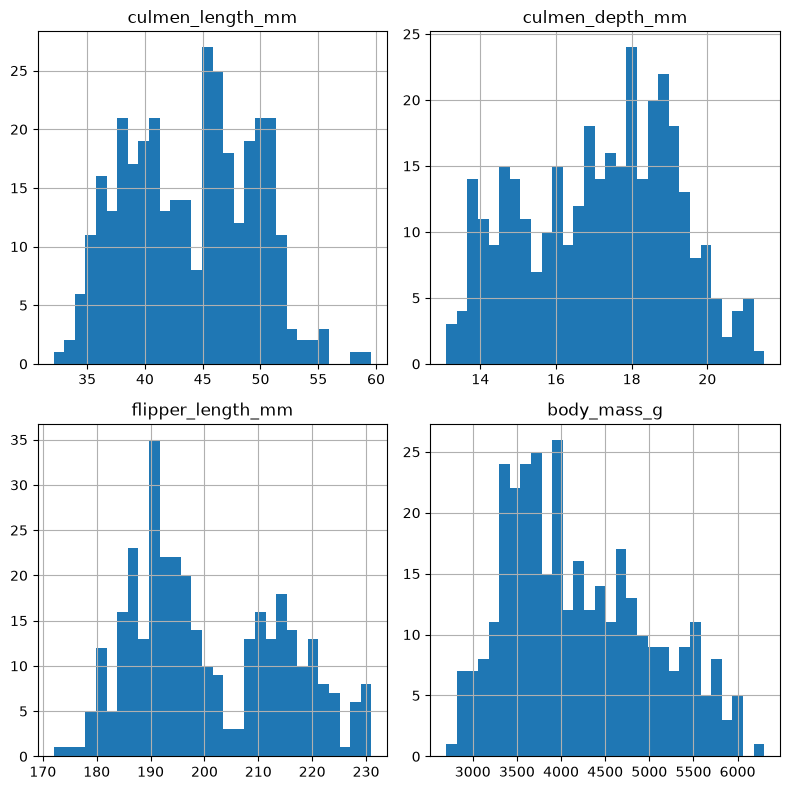

In [20]:
df[numeric_cols].hist(bins=30, figsize=(8, 8))

plt.tight_layout()
plt.show()

Видны потенциальные выбросы на 1-й и 4-й гистрограмме, проанализируем через IQR.

Выбросы будем считать по видам.

=== culmen_length_mm ===
Adelie: 0 выбросов -> []
Chinstrap: 0 выбросов -> []
Gentoo: 1 выбросов -> [59.6]

=== culmen_depth_mm ===
Adelie: 1 выбросов -> [21.5]
Chinstrap: 0 выбросов -> []
Gentoo: 0 выбросов -> []

=== flipper_length_mm ===
Adelie: 2 выбросов -> [172.0, 210.0]
Chinstrap: 0 выбросов -> []
Gentoo: 0 выбросов -> []

=== body_mass_g ===
Adelie: 0 выбросов -> []
Chinstrap: 2 выбросов -> [4800.0, 2700.0]
Gentoo: 0 выбросов -> []



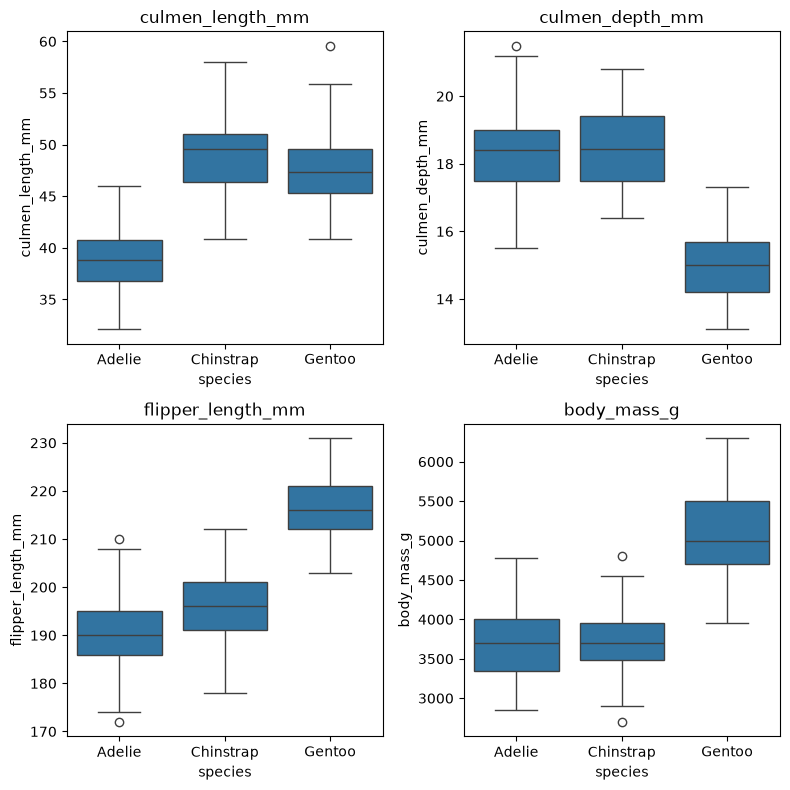

In [22]:
import seaborn as sns

def find_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

for col in numeric_cols:
    print(f"=== {col} ===")
    for sp, group in df.groupby("species"):
        outliers = find_outliers_iqr(group[col])
        print(f"{sp}: {len(outliers)} выбросов -> {outliers.tolist()}")
    print()

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x="species", y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Пропущенные значения

In [23]:
df.isnull().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

Строки, в которых пропущен пол -- удалить (можно, пытатся его определить по размерам тела). Остальные значения заполнить средним.

In [25]:
df = df.dropna(subset=["sex"])

df.isnull().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

Пропущенных значений не осталось.

# Корреляции

In [26]:
df[numeric_cols].corr()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,-0.228640,0.652126,0.589066
culmen_depth_mm,-0.228640,1.000000,-0.578730,-0.472987
flipper_length_mm,0.652126,-0.578730,1.000000,0.873211
body_mass_g,0.589066,-0.472987,0.873211,1.000000


### Анализ

Высокая корреляция ($|\operatorname{corr}| > 0.8$):
- $\operatorname{corr}(\text{flipper\_length\_mm}, \text{body\_mass\_g}) \approx 0.87$, прямая

Умеренная корреляция:
- $\operatorname{corr}(\text{culmen\_length\_mm}, \text{flipper\_length\_mm}) \approx 0.65$, прямая
- $\operatorname{corr}(\text{culmen\_length\_mm}, \text{body\_mass\_g}) \approx 0.59$, прямая
- $\operatorname{corr}(\text{culmen\_depth\_mm}, \text{flipper\_length\_mm}) \approx -0.58$, обратная
- $\operatorname{corr}(\text{culmen\_depth\_mm}, \text{body\_mass\_g}) \approx -0.47$, обратная

Слабая корреляция:
- $\operatorname{corr}(\text{culmen\_length\_mm}, \text{culmen\_depth\_mm}) \approx -0.23$, обратная — самая слабая связь среди всех пар.

Атрибутов, вообще не имеющих корреляции ($|\operatorname{corr}| < 0.1$), в датасете нет — все числовые пары связаны хотя бы слабо.

Если разделить все по видам, возможно, корреляции будут прослеживатся четче.

### Матрица графиков рассеивания

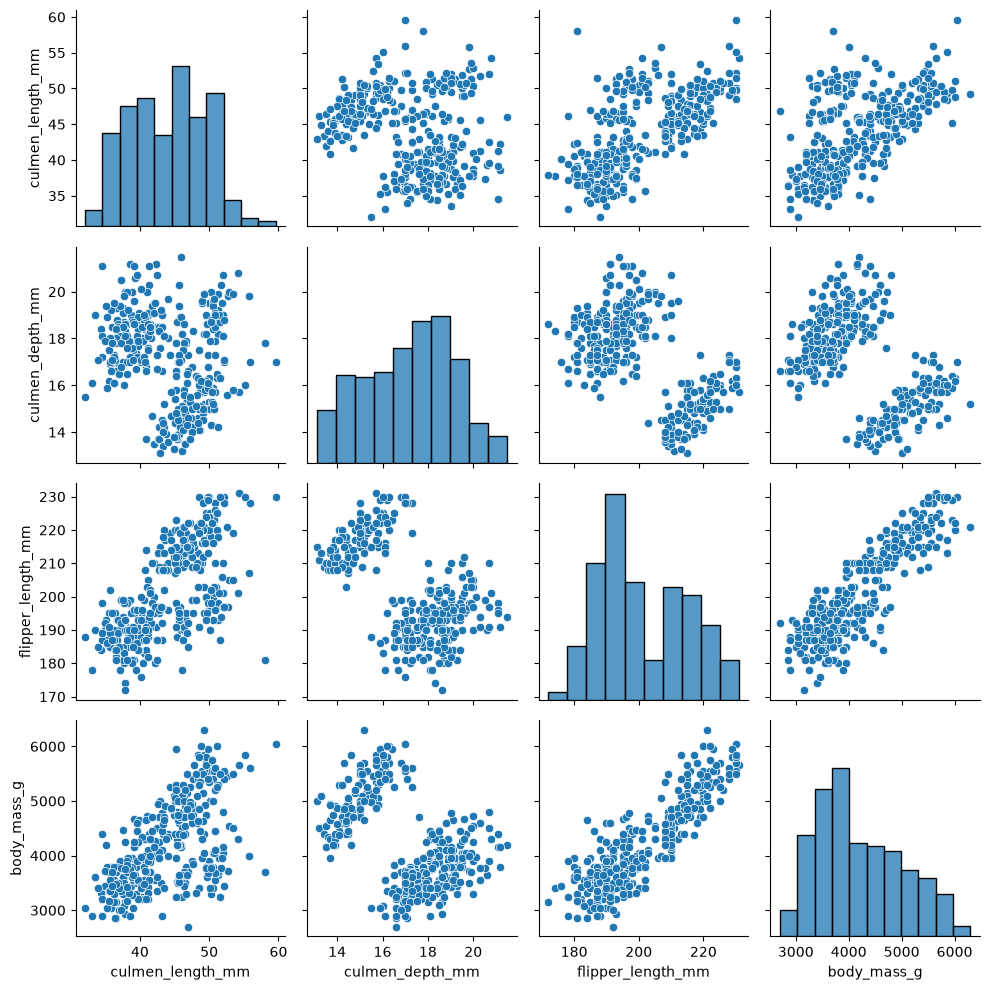

In [32]:
sns.pairplot(df[numeric_cols])

plt.tight_layout()
plt.show()

### Анализ

**Общая картина.** На большинстве пар признаков точки образуют не единое облако, а **два-три чётко различимых скопления** — это видно уже без разбивки по `species` цветом. Особенно заметно на парах:

- `culmen_length_mm` – `culmen_depth_mm` — два ярко выраженных кластера, разнесённых по вертикали
- `culmen_depth_mm` – `flipper_length_mm` и `culmen_depth_mm` – `body_mass_g` — аналогично, два хорошо отделённых облака

Это прямое следствие того, что в данных **смешаны три вида пингвинов**, у которых разные типичные пропорции тела. Именно поэтому графики с участием `culmen_depth_mm` выглядят наиболее "расслоёнными" — этот признак сильнее всего различается между видами.